# Report figures: combined baseline overview and redesigned phase 7 economics plots

Goal: rebuild three report figures purely from the saved npz summaries in `../results/data`. No simulation runs; numpy and matplotlib only.

- `phase_01_baseline_overview.png`: the three phase 1 plots (log-price path, return series, return histogram) combined into one three-panel figure.
- `phase_07_net_profit_vs_adoption.png`: net profit vs adoption share at four representative cost levels, with standard-error bands instead of the old standard-deviation wash.
- `phase_07_a_star_profit_vs_cost.png`: profit thresholds over the full cost grid, with cost levels that produce no crossing marked explicitly as not reached.

In [1]:
# Input npz summaries (written by the phase 1 and phase 7 notebooks).
baseline_npz = "../results/data/phase_01_baseline.npz"
costs_npz = "../results/data/phase_07_transaction_costs.npz"

# Output directory for the report figures.
fig_dir = "../results/figures"

# Adoption-share bins with this many observations or fewer are dropped, matching the phase 7 plot rule.
min_bin_count = 10

# Histogram bins for the baseline return distribution (matches phase 1).
hist_bins = 60

# Base font size: the report is set in 12pt, so keep panels legible at full text width.
font_size = 11

In [2]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["font.size"] = font_size

In [3]:
base = np.load(baseline_npz)
prices = base["prices"]
returns = base["returns"]
phi_input = float(base["phi_input"])
phi_empirical = float(base["phi_empirical"])
base_seed = int(base["seed"])

costs = np.load(costs_npz)
c_grid = costs["c_grid"]
bin_centers = costs["bin_centers"]
abs_means = costs["binned_abs_means"]
abs_stds = costs["binned_abs_stds"]
rel_means = costs["binned_rel_means"]
rel_stds = costs["binned_rel_stds"]
counts = costs["binned_counts"]
a_star_abs = costs["a_star_profit_abs"]
a_star_rel = costs["a_star_profit_rel"]
num_seeds = int(costs["num_seeds"])

## Combined baseline overview (phase 1)

Three stacked panels replicate the three separate phase 1 figures in one place: the log-price path, the one-period return series with a zero line, and the return histogram against a Gaussian built from the empirical mean and standard deviation. Content is unchanged from the originals; only the layout is combined.

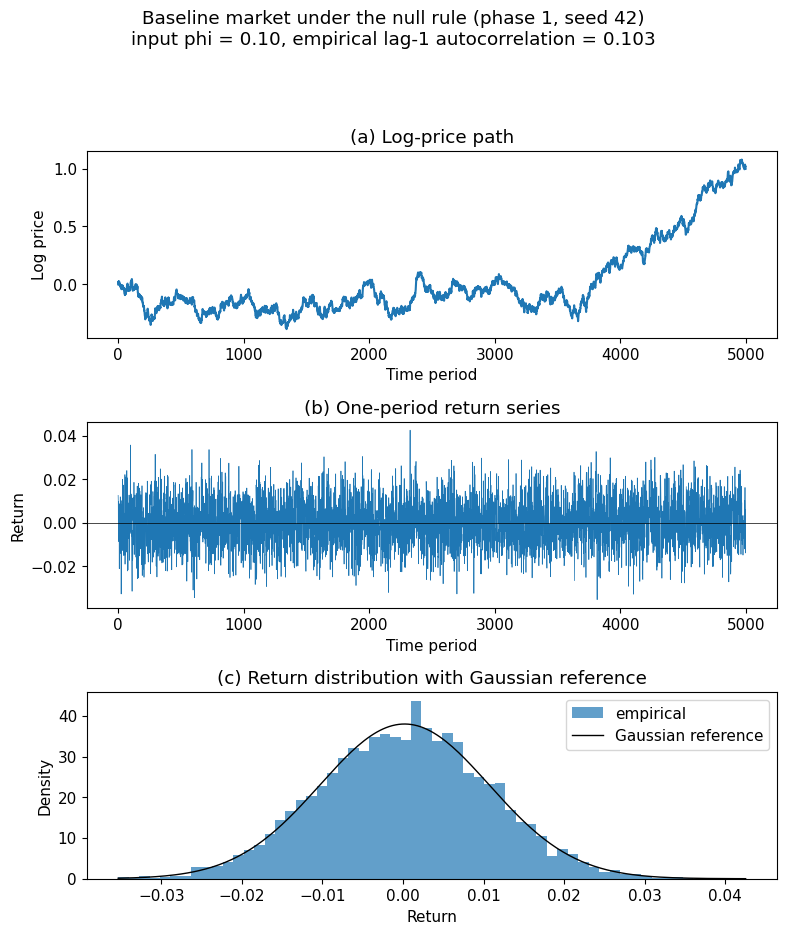

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(8, 9.5))

axes[0].plot(prices)
axes[0].set_title("(a) Log-price path")
axes[0].set_xlabel("Time period")
axes[0].set_ylabel("Log price")

axes[1].plot(returns, linewidth=0.5)
axes[1].axhline(0.0, color="k", linewidth=0.5)
axes[1].set_title("(b) One-period return series")
axes[1].set_xlabel("Time period")
axes[1].set_ylabel("Return")

axes[2].hist(returns, bins=hist_bins, density=True, alpha=0.7, label="empirical")
xs = np.linspace(returns.min(), returns.max(), 200)
mu_emp = returns.mean()
sd_emp = returns.std()
ys = np.exp(-0.5 * ((xs - mu_emp) / sd_emp) ** 2) / (sd_emp * np.sqrt(2 * np.pi))
axes[2].plot(xs, ys, "k-", linewidth=1.0, label="Gaussian reference")
axes[2].set_title("(c) Return distribution with Gaussian reference")
axes[2].set_xlabel("Return")
axes[2].set_ylabel("Density")
axes[2].legend()

fig.suptitle(
    f"Baseline market under the null rule (phase 1, seed {base_seed})\n"
    f"input phi = {phi_input:.2f}, empirical lag-1 autocorrelation = {phi_empirical:.3f}"
)
fig.tight_layout(rect=(0, 0, 1, 0.93))
fig.savefig(f"{fig_dir}/phase_01_baseline_overview.png", dpi=150)
plt.show()

## Net profit vs adoption share at four representative cost levels (phase 7)

Cost levels shown: c = 0, the two levels where the absolute curve crosses zero (read from `a_star_profit_abs`), and the largest cost on the grid. Bands are plus or minus one standard error of the bin mean (standard deviation over the square root of the bin count), so the mean lines carry the comparison rather than the seed-level dispersion. Bins at or below `min_bin_count` observations are dropped, which ends the curves short of full adoption. The inset zooms on the c = 0 null-relative curve, which sits slightly below zero at almost every observed share.

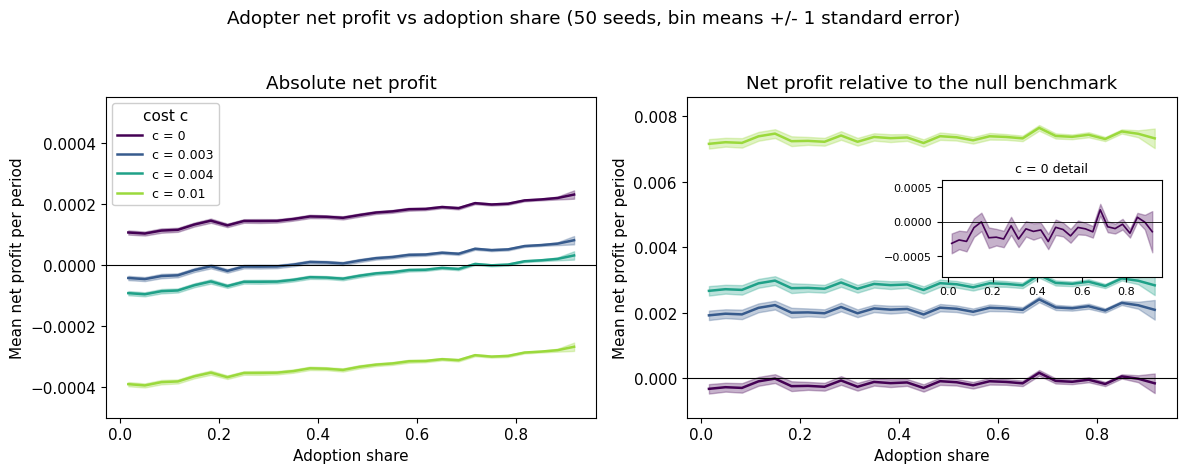

In [5]:
crossing_idx = np.flatnonzero(np.isfinite(a_star_abs))
sel = sorted({0, *crossing_idx.tolist(), len(c_grid) - 1})
colours = plt.cm.viridis(np.linspace(0.0, 0.85, len(sel)))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), sharex=True)
panels = [
    (axes[0], abs_means, abs_stds, "Absolute net profit"),
    (axes[1], rel_means, rel_stds, "Net profit relative to the null benchmark"),
]
for ax, means, stds, title in panels:
    for k, colour in zip(sel, colours):
        valid = counts[k] > min_bin_count
        se = stds[k][valid] / np.sqrt(counts[k][valid])
        ax.plot(bin_centers[valid], means[k][valid], color=colour, linewidth=1.8,
                label=f"c = {c_grid[k]:g}")
        ax.fill_between(bin_centers[valid], means[k][valid] - se, means[k][valid] + se,
                        color=colour, alpha=0.3)
    ax.axhline(0.0, color="k", linewidth=0.8)
    ax.set_title(title)
    ax.set_xlabel("Adoption share")
    ax.set_ylabel("Mean net profit per period")

axes[0].set_ylim(-5.0e-4, 5.5e-4)
axes[0].legend(title="cost c", loc="upper left", fontsize=9, framealpha=0.95)
axes[1].set_ylim(-1.2e-3, 8.6e-3)

inset = axes[1].inset_axes([0.52, 0.44, 0.45, 0.30])
valid0 = counts[0] > min_bin_count
se0 = rel_stds[0][valid0] / np.sqrt(counts[0][valid0])
inset.plot(bin_centers[valid0], rel_means[0][valid0], color=colours[0], linewidth=1.2)
inset.fill_between(bin_centers[valid0], rel_means[0][valid0] - se0, rel_means[0][valid0] + se0,
                   color=colours[0], alpha=0.3)
inset.axhline(0.0, color="k", linewidth=0.6)
inset.set_ylim(-8.0e-4, 6.0e-4)
inset.set_title("c = 0 detail", fontsize=9)
inset.tick_params(labelsize=8)

fig.suptitle(f"Adopter net profit vs adoption share ({num_seeds} seeds, bin means +/- 1 standard error)")
fig.tight_layout(rect=(0, 0, 1, 0.95))
fig.savefig(f"{fig_dir}/phase_07_net_profit_vs_adoption.png", dpi=150, bbox_inches="tight")
plt.show()

## Profit thresholds across the full cost grid (phase 7)

For each cost level the absolute and null-relative crossing shares are plotted where a crossing exists. Levels with no crossing are pinned as open markers in the shaded band above A = 1, so the sparseness of crossings is itself visible. The single null-relative crossing at c = 0 is a bin-noise wobble around a slightly negative mean; it is drawn de-emphasised and annotated, not presented as a threshold reading.

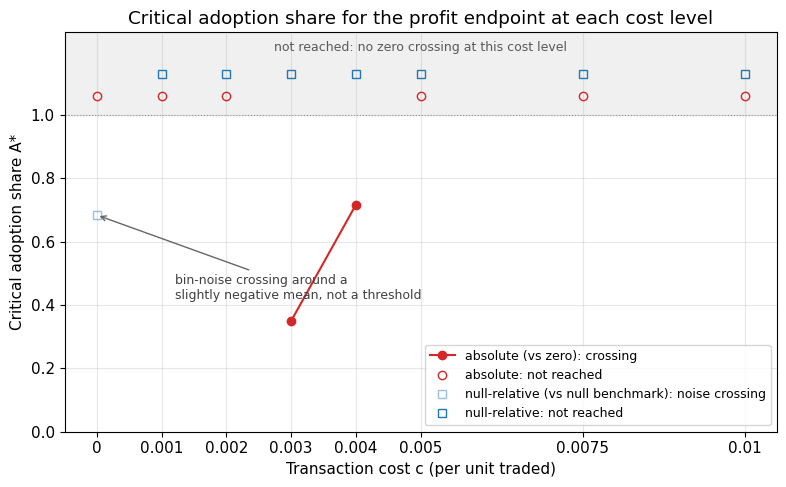

In [6]:
abs_found = np.isfinite(a_star_abs)
rel_found = np.isfinite(a_star_rel)
y_abs_na, y_rel_na = 1.06, 1.13

fig, ax = plt.subplots(figsize=(8, 5))
ax.axhspan(1.0, 1.26, color="0.94", zorder=0)
ax.axhline(1.0, color="0.6", linewidth=0.8, linestyle=":")
ax.text(0.005, 1.20, "not reached: no zero crossing at this cost level",
        ha="center", fontsize=9, color="0.35")

ax.plot(c_grid[abs_found], a_star_abs[abs_found], marker="o", color="C3",
        linewidth=1.5, label="absolute (vs zero): crossing")
ax.plot(c_grid[~abs_found], np.full((~abs_found).sum(), y_abs_na), linestyle="none",
        marker="o", markerfacecolor="none", color="C3", label="absolute: not reached")

ax.plot(c_grid[rel_found], a_star_rel[rel_found], linestyle="none", marker="s",
        markerfacecolor="none", color="C0", alpha=0.45, markersize=6,
        label="null-relative (vs null benchmark): noise crossing")
ax.plot(c_grid[~rel_found], np.full((~rel_found).sum(), y_rel_na), linestyle="none",
        marker="s", markerfacecolor="none", color="C0", label="null-relative: not reached")

ax.annotate("bin-noise crossing around a\nslightly negative mean, not a threshold",
            xy=(float(c_grid[0]), float(a_star_rel[0])), xytext=(0.0012, 0.42),
            arrowprops=dict(arrowstyle="->", color="0.4"), fontsize=9, color="0.25")

ax.set_xticks(c_grid)
ax.set_xticklabels([f"{c:g}" for c in c_grid])
ax.set_yticks(np.arange(0.0, 1.01, 0.2))
ax.set_ylim(0.0, 1.26)
ax.set_xlabel("Transaction cost c (per unit traded)")
ax.set_ylabel("Critical adoption share A*")
ax.set_title("Critical adoption share for the profit endpoint at each cost level")
ax.grid(True, alpha=0.3)
ax.legend(loc="lower right", fontsize=9)
fig.tight_layout()
fig.savefig(f"{fig_dir}/phase_07_a_star_profit_vs_cost.png", dpi=150)
plt.show()

## Done when

- `phase_01_baseline_overview.png` shows the same three panels as the original phase 1 figures, stacked under one shared title.
- `phase_07_net_profit_vs_adoption.png` shows four cost levels with standard-error bands, absolute profit rising with adoption and ordered by cost, the c = 0 null-relative curve slightly negative throughout (inset), and every positive-cost null-relative curve uniformly positive.
- `phase_07_a_star_profit_vs_cost.png` spans the full cost grid, marks not-reached levels explicitly, and de-emphasises the c = 0 noise crossing.